# MNIST

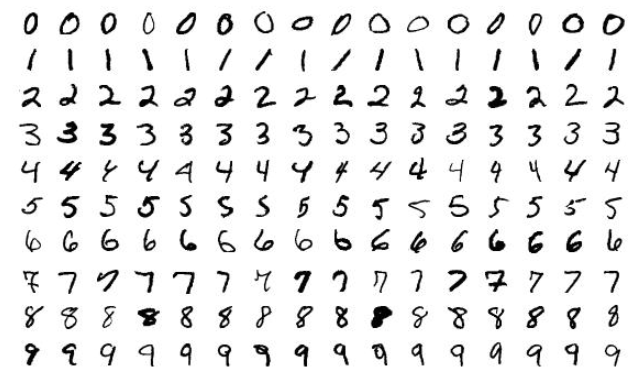


* El dataset MNIST contiene 60,000 imágenes de entrenamiento y 10,000 imágenes de prueba de dígitos escritos a mano (del 0 al 9).
* Cada imagen es en escala de grises (blanco y negro) y tiene un tamaño de 28x28 píxeles, lo que da como resultado 784 características por imagen        (28x28=784).
* Los valores de cada píxel están representados por números entre 0 y 255, donde 0 es blanco (fondo) y 255 es negro (trazo). Otros valores intermedios representan diferentes niveles de gris.


# Autoencoder en Python (Clase 29)Recurso descargable del Módulo 6. Entrena **cuatro autoencoders** sobre MNIST, de menor a mayor complejidad:| # | Modelo | Arquitectura | `val_loss` final ||---|--------|--------------|------------------|| 1 | Autoencoder simple | 784 → 32 → 784, densa | 0,0916 || 2 | Autoencoder profundo | 784 → 128 → 64 → 32 → 64 → 128 → 784 | 0,0878 || 3 | Autoencoder convolucional | Conv2D + MaxPooling / UpSampling | 0,0935 || 4 | Autoencoder para eliminación de ruido | igual al 3, pero entrada con ruido | **0,1909** |Los valores de la tabla salen de ejecutar el notebook completo (50 épocas cada modelo, TensorFlow 2.21). Los tres primeros terminan donde se espera; el cuarto cierra en más del doble de pérdida, y eso **no** es inherente al denoising: es consecuencia de un error en el código del material, documentado en la sección 4.> **Nota sobre la pérdida.** Los cuatro modelos usan `binary_crossentropy`, que aquí no mide clasificación sino reconstrucción píxel a píxel. Funciona porque las imágenes están normalizadas a `[0,1]` y la salida del decoder es `sigmoid`, con lo cual cada píxel se trata como una probabilidad. Las pérdidas de modelos distintos solo son comparables si el *target* es el mismo: los modelos 1 a 3 reconstruyen `X_train` a partir de `X_train`, así que se comparan entre sí; el modelo 4 reconstruye `X_train` a partir de `X_train_noisy`, que es una tarea distinta y más difícil.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

## 1. Autoencoder simpleUna sola capa oculta de 32 unidades: la imagen de 784 píxeles se comprime a 32 números y se reconstruye desde ahí. La compresión es de 24,5 a 1.

AUTOENCODER SIMPLE

In [ ]:
(X_train, y_train),(X_test,_) = tf.keras.datasets.mnist.load_data()

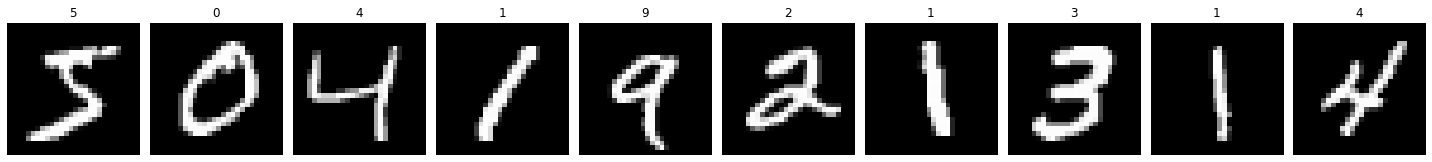

In [ ]:
plt.figure(figsize=(20, 4))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'{y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Se normaliza a `[0,1]` dividiendo por 255. Es lo que habilita usar `sigmoid` en la salida y `binary_crossentropy` como pérdida.Notar que `y_train` (las etiquetas) solo se usa para los títulos del gráfico anterior. Un autoencoder es **auto-supervisado**: el target es la propia entrada, las etiquetas no intervienen en el entrenamiento.

In [ ]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

print('X_train_shape: ', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train_shape:  (60000, 28, 28)
60000 train samples
10000 test samples


Aplanado de `(60000, 28, 28)` a `(60000, 784)`, necesario porque este primer modelo es totalmente conectado y no convolucional.

In [ ]:
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


El modelo se arma con la API funcional, y de esa misma construcción se derivan **tres** modelos que comparten pesos:- `autoencoder`: entrada → código → reconstrucción. Es el que se entrena.- `encoder`: entrada → código. Sirve para obtener la representación comprimida.- `decoder`: código → reconstrucción. Sirve para decodificar un código arbitrario.Los dos últimos no se entrenan por separado: son vistas del mismo grafo de capas. Entrenar `autoencoder` actualiza los pesos que `encoder` y `decoder` reutilizan.

In [ ]:
ENCODING_DIM = 32
input_img = tf.keras.layers.Input(shape=(784,))
encoded = tf.keras.layers.Dense(ENCODING_DIM, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)
autoencoder = tf.keras.models.Model(input_img, decoded)

In [ ]:
encoder = tf.keras.models.Model(input_img, encoded)

In [ ]:
encoded_input = tf.keras.layers.Input(shape=(ENCODING_DIM,))
decoder_layer = autoencoder.layers[-1]
decoder = tf.keras.models.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

`fit(X_train, X_train, ...)`: entrada y target son el mismo tensor. Ahí está la idea central del autoencoder — el objetivo es copiar la entrada, y lo único que impide la copia trivial es el cuello de botella de 32 unidades, que fuerza a quedarse con lo que más información aporta.

In [ ]:
history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3890 - val_loss: 0.1882
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1791 - val_loss: 0.1527
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1490 - val_loss: 0.1332
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1313 - val_loss: 0.1204
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1199 - val_loss: 0.1124
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1121 - val_loss: 0.1064
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1065 - val_loss: 0.1020
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1025 - val_loss: 0.0988
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0995 - val_loss: 0.0968
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0975 - val_loss: 0.0952
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0961 - val_loss: 0.0941
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [ ]:
encoded_imgs = encoder.predict(X_test)

decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step


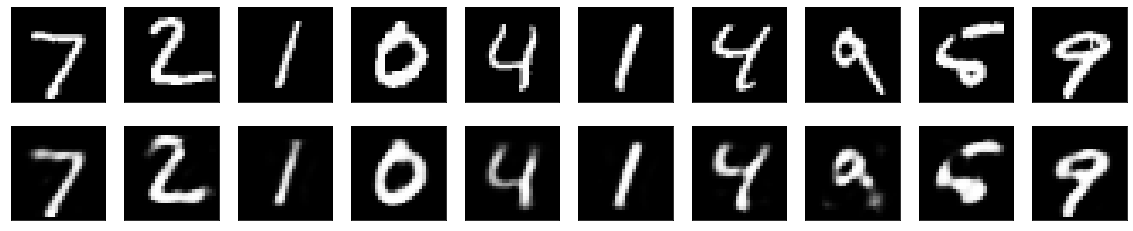

In [ ]:
plt.figure(figsize=(20, 4))
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

El código de 32 dimensiones, activado con `relu`, es disperso: buena parte de las componentes queda en cero exacto. No es un efecto buscado, sino la consecuencia natural de `relu` en la capa del cuello de botella.

In [ ]:
print(encoded_imgs.shape)
print(encoded_imgs)

## 2. Autoencoder con varias capas ocultasMismo cuello de botella (32), pero con una reducción gradual 784 → 128 → 64 → 32 y su espejo en el decoder. Baja la pérdida de 0,0916 a 0,0878: más capacidad permite una compresión mejor al mismo tamaño de código.> **Nota:** la constante `ENCODING_DIM` se define de nuevo pero no se usa — las dimensiones están escritas a mano en cada capa. Es inofensivo, pero si se cambia `ENCODING_DIM` esperando que cambie el modelo, no pasa nada.

AUTOENCODER CON VARIAS CAPAS OCULTAS

In [ ]:
(X_train, _),(X_test,_) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

In [ ]:
ENCODING_DIM = 32
input_img = tf.keras.layers.Input(shape=(784,))
encoded = tf.keras.layers.Dense(128, activation='relu')(input_img)
encoded = tf.keras.layers.Dense(64, activation='relu')(encoded)
encoded = tf.keras.layers.Dense(32, activation='relu')(encoded)

decoded = tf.keras.layers.Dense(64, activation='relu')(encoded)
decoded = tf.keras.layers.Dense(128, activation='relu')(decoded)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = tf.keras.models.Model(input_img, decoded)

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

history2 = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3426 - val_loss: 0.1709
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1633 - val_loss: 0.1400
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1372 - val_loss: 0.1271
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1272 - val_loss: 0.1208
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1211 - val_loss: 0.1160
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1163 - val_loss: 0.1126
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1134 - val_loss: 0.1097
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1107 - val_loss: 0.1073
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1079 - val_loss: 0.1051
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1062 - val_loss: 0.1035
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1041 - val_loss: 0.1022
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

In [ ]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


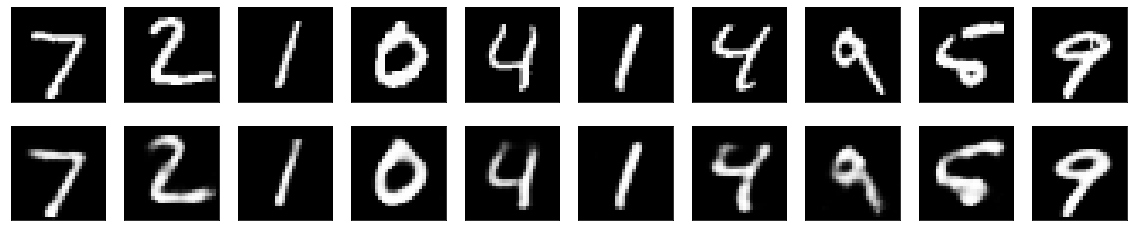

In [ ]:
plt.figure(figsize=(20, 4))
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## 3. Autoencoder convolucionalAcá no se aplana la imagen: se trabaja sobre `(28, 28, 1)`. El encoder reduce con `MaxPooling2D` y el decoder amplía con `UpSampling2D`.> **Nota sobre el `padding`.** Todas las convoluciones usan `padding='same'` excepto la anteúltima del decoder, `Conv2D(16, (3, 3), activation='relu')`, que va sin `padding`. No es un descuido: después de dos `UpSampling2D` el tensor mide 14×14, y una convolución 3×3 sin padding lo lleva a 12×12, que tras el último `UpSampling2D` da los 28×28 buscados. Con `padding='same'` en todas, la salida terminaría en 32×32 y el modelo ni siquiera compilaría contra un target de 28×28.La pérdida (0,0935) queda apenas por encima de la del modelo denso profundo. Con 50 épocas y este tamaño de código, la ventaja convolucional todavía no se nota.

AUTOENCODER CON CNN

In [ ]:
(X_train, _),(X_test,_) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

print(X_train.shape)

X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1))

print(X_train.shape)

(60000, 28, 28)
(60000, 28, 28, 1)


In [ ]:
input_img = tf.keras.layers.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = tf.keras.models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
history3 = autoencoder.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.3944 - val_loss: 0.1696
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1625 - val_loss: 0.1449
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1435 - val_loss: 0.1354
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1345 - val_loss: 0.1276
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1272 - val_loss: 0.1223
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1223 - val_loss: 0.1188
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1188 - val_loss: 0.1158
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1162 - val_loss: 0.1134
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1140 - val_loss: 0.1118
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1122 - val_loss: 0.1100
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1108 - val_loss: 0.1089
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


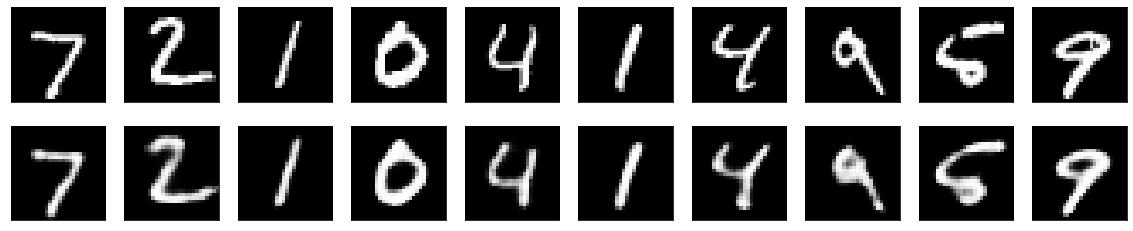

In [ ]:
plt.figure(figsize=(20, 4))
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## 4. Autoencoder para eliminación de ruidoEs el único de los cuatro donde entrada y target **difieren**: se entrena `X_train_noisy → X_train`. El modelo no aprende a copiar, aprende a limpiar. Es la variante *denoising*, y la arquitectura es idéntica a la del modelo 3.> **Bug en el material.** La celda que sigue construye el ruido así:>> ```python> X_train_noisy = X_train + noise_factor + np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)> ```>> El segundo `+` tendría que ser `*`. Tal como está, `noise_factor` no escala el ruido: le suma 0,5 de brillo constante a toda la imagen, y el ruido entra con desviación 1,0 en vez de 0,5. O sea, el doble de ruido del previsto **más** un desplazamiento que empuja todo hacia el blanco, que el `np.clip` posterior satura.>> Medido sobre MNIST, comparando la versión del material contra la corregida:>> | | Versión del material (`+`) | Versión correcta (`*`) |> |---|---|---|> | Media de intensidad | 0,545 | 0,275 |> | Píxeles saturados en blanco | 35,9 % | 7,8 % |> | Correlación con la imagen original | 0,241 | 0,553 |>> Con el `+`, más de un tercio de los píxeles se satura en 1,0 y la correlación con el dígito original cae a menos de la mitad: se destruye buena parte de la señal que el modelo tendría que recuperar. Eso explica la `val_loss` de 0,1909, el doble que la de los otros tres modelos.>> La línea correcta es:>> ```python> X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)> ```>> El código original se deja tal cual está para que el notebook siga siendo fiel al recurso del curso. Vale la pena correrlo de las dos formas y comparar las imágenes: el ejemplo sigue "funcionando" —el modelo reconstruye dígitos legibles— y por eso el error pasa desapercibido. Es el patrón recurrente de este material: **fallas que no lanzan ninguna excepción**.

AUTOENCODER PARA ELIMINACIÓN DE RUIDO

In [ ]:
(X_train, y_train),(X_test,_) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1))

In [ ]:
noise_factor = 0.5
X_train_noisy = X_train + noise_factor + np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor + np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

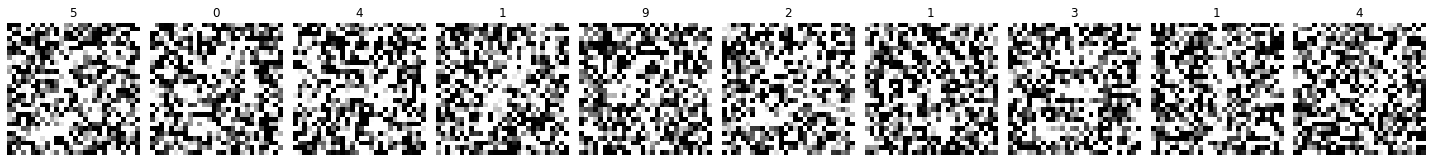

In [ ]:
plt.figure(figsize=(20, 4))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train_noisy[i], cmap='gray')
    plt.title(f'{y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
input_img = tf.keras.layers.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = tf.keras.models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
history4 = autoencoder.fit(X_train_noisy, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test_noisy, X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.3780 - val_loss: 0.2581
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.2503 - val_loss: 0.2343
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.2326 - val_loss: 0.2277
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2263 - val_loss: 0.2219
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2219 - val_loss: 0.2183
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2181 - val_loss: 0.2131
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2139 - val_loss: 0.2102
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2107 - val_loss: 0.2079
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2080 - val_loss: 0.2056
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.2067 - val_loss: 0.2039
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.2045 - val_loss: 0.2022
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━

El resultado es la mejor demostración del punto: incluso con una entrada tan degradada, el modelo recupera dígitos reconocibles. Un autoencoder de eliminación de ruido no memoriza la imagen sucia, aprende la estructura de lo que un dígito de MNIST puede ser, y proyecta la entrada sobre esa estructura.---## Resumen de hallazgos sobre el material| Hallazgo | Gravedad | Detalle ||----------|----------|---------|| `+ noise_factor` en vez de `* noise_factor` | **Alta** | Sección 4. Duplica el ruido y satura el 36 % de los píxeles en blanco; `val_loss` 0,1909 contra ~0,093 de los otros modelos || `ENCODING_DIM` redefinido y no usado | Baja | Sección 2. Las dimensiones están escritas a mano; cambiar la constante no cambia el modelo |Verificado y **correcto**, pese a que parecen errores a primera vista:- La convolución sin `padding='same'` en el decoder es deliberada y necesaria para cerrar en 28×28.- `binary_crossentropy` sobre píxeles continuos en `[0,1]` es válido, no un uso indebido de una pérdida de clasificación.- Recargar el dataset al principio de cada sección es redundante pero correcto: evita arrastrar el `reshape` de la sección anterior.Las cuatro corridas se ejecutaron completas, 50 épocas cada una, con TensorFlow 2.21 sobre el kernel `dl-env`, sin ningún error.

In [ ]:
decoded_imgs = autoencoder.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


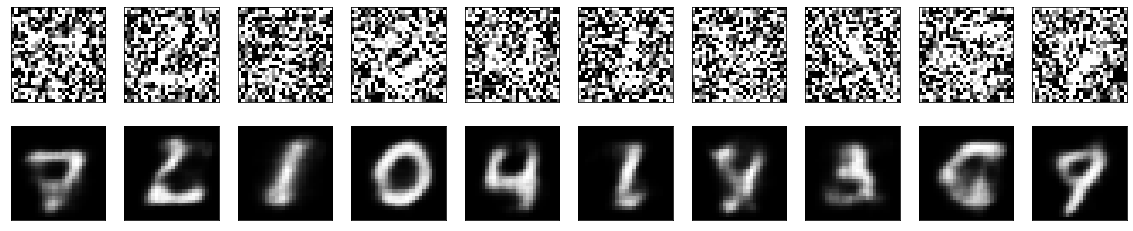

In [ ]:
plt.figure(figsize=(20, 4))
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 1 + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()